## Setup
Import dependencies, set seeds, and configure paths and plotting defaults.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import seaborn as sns
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
import os
import pandas as pd
import scbiot as scb
from scbiot.utils import set_seed

import harmonypy as hm
from umap import UMAP
# %pip install scib-metrics
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

set_seed(42)

from pathlib import Path
dir = Path.cwd()
print(dir)
parent_dir = dir.parent
print(parent_dir)

from scimorph.theme_publication import theme_publication
from scimorph.utils import set_seed
theme_publication()


## Load
Read the paired multiome dataset from disk.

In [16]:
adata_gex_path = f'{dir}/inputs/Chen-2019-RNA.h5ad'
adata_atac_path = f'{dir}/inputs/Chen-2019-ATAC.h5ad'

adata_gex = sc.read(
    adata_gex_path,
    backup_url="https://figshare.com/ndownloader/files/59742638",
)

adata_atac = sc.read(
    adata_atac_path,
    backup_url="https://figshare.com/ndownloader/files/59742644",
)

In [17]:
# --- Combine paired snRNA + snATAC into one AnnData (vars = genes ∪ peaks) ---
import anndata as ad
import numpy as np
import pandas as pd
from scipy.sparse import issparse, csr_matrix

def _to_csr32(X):
    if issparse(X):
        X = X.tocsr(copy=False)
        if X.dtype != np.float32:
            X = X.astype(np.float32)
        return X
    # dense → sparse
    X = csr_matrix(X)
    if X.dtype != np.float32:
        X = X.astype(np.float32)
    return X

# ---------------- 0) Sanity & hard alignment of cells ----------------
# Ensure identical cell sets
cells_gex  = pd.Index(adata_gex.obs_names.astype(str))
cells_atac = pd.Index(adata_atac.obs_names.astype(str))

if set(cells_gex) != set(cells_atac):
    missing_in_atac = cells_gex.difference(cells_atac)
    missing_in_gex  = cells_atac.difference(cells_gex)
    raise ValueError(
        f"Cell sets are not identical:\n"
        f"  missing_in_atac: {len(missing_in_atac)}\n"
        f"  missing_in_gex : {len(missing_in_gex)}"
    )

# Reorder ATAC to match GEX exactly (critical!)
adata_atac = adata_atac[cells_gex].copy()

# ---------------- 1) Tag modality in var['feature_types'] -------------
# NOTE: you had a small bug: use '=' not '==' for assignment.
adata_gex.var["feature_types"]  = "GEX"
adata_atac.var["feature_types"] = "ATAC"

# (Optional) a scvi-style alias if you need it later
# map_ft = {"GEX": "Gene Expression", "ATAC": "Peaks"}
# for a in (adata_gex, adata_atac):
#     a.var["feature_types_scvi"] = a.var["feature_types"].map(map_ft)

# Make feature names unique within each modality (no-op if already unique)
adata_gex.var_names_make_unique()
adata_atac.var_names_make_unique()

# ---------------- 2) Ensure a 'counts' layer and CSR float32 ----------
def ensure_counts_layer(a):
    if "counts" not in a.layers:
        a.layers["counts"] = a.X.copy()  # treat current X as counts
    # Keep X as counts too (simple & consistent for concatenation)
    a.layers["counts"] = _to_csr32(a.layers["counts"])
    a.X = a.layers["counts"]  # X=counts; you can normalize into a new layer later

ensure_counts_layer(adata_gex)
ensure_counts_layer(adata_atac)

# ---------------- 3) Concatenate along variables (genes + peaks) ------
# This keeps obs identical, stacks features, merges layers by name.
adata = ad.concat(
    [adata_gex, adata_atac],
    axis=1,                 # concatenate columns (features)
    join="outer",           # union of var columns
    label=None,             # no key added to obs
    merge="first",          # for shared .obs/.var columns, take first non-null
)

# ---------------- 4) Carry over embeddings (if present & useful) ------
# You can keep separate views in obsm for convenience
for key in ("X_pca", "X_umap", "X_tsne", "X_lsi"):
    if key in adata_gex.obsm:
        adata.obsm[f"{key}_gex"] = adata_gex.obsm[key]
    if key in adata_atac.obsm:
        adata.obsm[f"{key}_atac"] = adata_atac.obsm[key]

# ---------------- 5) Quick report ------------------------------------
n_genes = (adata.var["feature_types"] == "GEX").sum() if "feature_types" in adata.var else np.nan
n_peaks = (adata.var["feature_types"] == "ATAC").sum() if "feature_types" in adata.var else np.nan
print(adata)
print(f"features: genes={n_genes}, peaks={n_peaks}")
print("layers:", list(adata.layers.keys()))
print("example var columns:", adata.var.columns[:10].tolist())


AnnData object with n_obs × n_vars = 9190 × 270687
    obs: 'domain', 'protocol', 'dataset', 'cell_type'
    var: 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_id', 'gene_type', 'mgi_id', 'havana_gene', 'tag', 'genome', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'feature_types'
    layers: 'counts'
features: genes=28930, peaks=241757
layers: ['counts']
example var columns: ['chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount']


In [18]:
# ---------------- 6) Batch / replicate labels from cell-id prefix -------------
import re

# Everything up to the first "_" or "-" is the batch id (e.g., "09A" from "09A_XXXX")
pat = r'^(?P<batch>[^_-]+)[_-]'

name_s = pd.Series(adata.obs_names.astype(str), index=adata.obs_names)
batch  = name_s.str.extract(pat)['batch'].fillna("UNK")

# Natural-sort categories so 9 < 10 (i.e., "09A", "09B", ..., "10A")
def _natkey(s):
    return [int(t) if t.isdigit() else t for t in re.split(r'(\d+)', str(s))]

cats = sorted(pd.unique(batch), key=_natkey)
adata.obs['batch'] = pd.Categorical(batch, categories=cats, ordered=True)

# Quick check
print("Batches:", list(adata.obs['batch'].cat.categories))
print(adata.obs['batch'].value_counts())


Batches: ['09A', '09B', '09C', '09D', '09E', '09F', '09G', '09H', '09I', '09J', '09K', '09L']
batch
09D    819
09G    809
09C    800
09F    799
09B    794
09I    781
09J    759
09K    749
09H    748
09A    721
09E    707
09L    704
Name: count, dtype: int64


## Preprocess
Split GEX/ATAC modalities and build PCA (RNA) plus LSI (ATAC) features.

In [19]:
# split to gex and peaks
gex_vars = adata.var['feature_types'] == 'GEX'
adata_gex = adata[:, gex_vars].copy()

# Filter for ATAC-related variables
atac_vars = adata.var['feature_types'] == 'ATAC'
adata_atac = adata[:, atac_vars].copy()

In [20]:

# 0) ATAC preprocessing (peak filtering -> LSI -> GA + smoothing)
# figshare link: https://figshare.com/ndownloader/files/59742641
gtf_file = f"{dir}/inputs/gencode.vM25.chr_patch_hapl_scaff.annotation.gtf.gz"

adata_ga = scb.pp.create_gene_activity(adata_atac, adata_gex, gtf_file=gtf_file, verbose=True)
adata_ga

Removed 25,110 promoter-proximal peaks (2000bp upstream / 500bp downstream). Remaining: 216,647
Running Iterative LSI iteration 1 ...
Running Iterative LSI iteration 2 ...
[GA] Kept 22,358/56,262 genes by biotype ['protein_coding', 'lncRNA']
[GA] Peaks contigs: 21; Genes contigs: 108; Common: 21
[GA] Using gene field: gene_name
[GA] Built GA with shape (9190, 17142) (cells × genes) from 241,757 peaks.
[names] Harmonized symbols; overlaps (case-insensitive): 15,517


AnnData object with n_obs × n_vars = 9190 × 17142
    obs: 'domain', 'protocol', 'dataset', 'cell_type', 'batch'
    var: 'n_peaks'
    uns: 'provenance'
    layers: 'ga', 'ga_smooth'

In [21]:
adata_gex.obs["cell_type"] = adata_gex.obs["cell_type"]
adata_ga.obs["cell_type"] = "Unknown"

adata_gex.X = adata_gex.layers['counts'] 

In [ ]:
adata = scb.pp.autoencoder_map(
    adata_gex, adata_ga,    
    label="modality",    
    # batch_key='batch',
    keys=("reference", "query"),        
    reference_layer="counts",        
    query_layer='ga_smooth',     
    label_key="cell_type",
    unlabeled_category="Unknown",
    out_key="X_ae",           
)
adata

## Integrate
Map the RNA reference and ATAC gene-activity query from the v1.2.0 linear-autoencoder space.

In [ ]:
adata, metrics = scb.ot.integrate(
    adata,
    obsm_key="X_ae",
    batch_key="modality",  
    prealign='ot',
    prealign_strength=0.8,  
    align_reference=True,
    label_key="cell_type",    
    unlabeled_category="Unknown",    
    out_key="X_supbiot"    
)


## Label transfer (supBIOT)


In [ ]:
adata = scb.ot.supbiot(
adata,
use_rep="X_supbiot",
label_key="cell_type",
unlabeled_category="Unknown",
pred_label_key='pred_cell_type',
pred_conf_key="pred_confidence",
min_conf=0.
)

In [25]:
adata_ga = adata[adata.obs['modality'] == 'query'].copy()
adata_gex = adata[adata.obs['modality'] == 'reference'].copy()
adata_ga.obs['pred_cell_type'].value_counts()

pred_cell_type
E2Rasgrf2     2931
E4Il1rapl2    1609
E3Rorb        1056
E6Tle4         977
E5Parm1        806
InP            491
Ast            450
OliM           234
E5Galnt14      210
E3Rmst          98
InV             97
InS             95
E4Thsd7a        74
E5Sulf1         15
Mic             15
OPC              9
Clau             8
InN              7
Peri             6
OliI             1
Endo             1
Name: count, dtype: int64

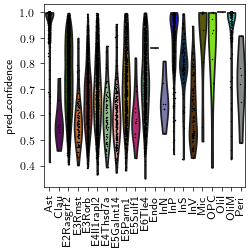

In [26]:
sc.pl.violin(adata_ga, keys="pred_confidence", groupby="pred_cell_type", rotation=90)

In [27]:
sc.pp.neighbors(adata, use_rep="X_supbiot", n_neighbors=50, metric="cosine")
sc.tl.umap(adata, min_dist=0.3, spread=1.0, random_state=0)

## Visualize
Compare batch and Leiden structure across embeddings in UMAP panels.

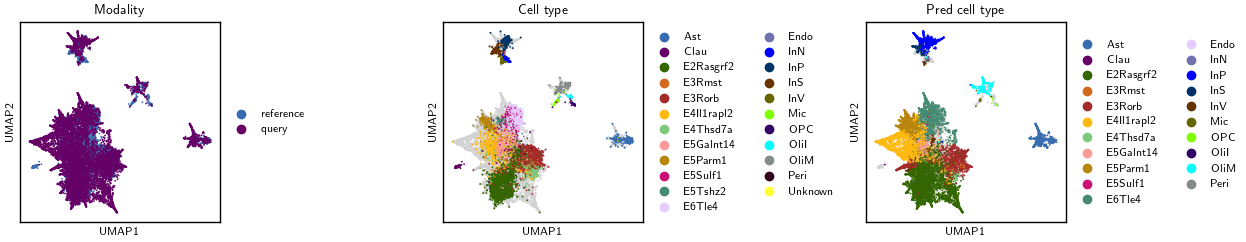

In [28]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scanpy as sc

sc.settings._vector_friendly = True
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1.0

def force_border(ax):
    ax.set_axis_on()
    ax.set_frame_on(True)
    ax.patch.set_visible(True)
    for side in ax.spines.values():
        side.set_visible(True)
        side.set_color("black")
        side.set_linewidth(1.0)

def mask_drop_unknown_na(adata, key, drop=("Unknown", "Unkown", "NA", "NaN", "None", "")):
    s = adata.obs[key].astype("string")
    low = s.str.strip().str.lower()
    drop_low = {d.lower() for d in drop}
    m = s.notna() & (~low.isin(drop_low))
    return m.to_numpy(dtype=bool, na_value=False)

methods = ["X_supbiot"]

m_cell = mask_drop_unknown_na(adata, "cell_type")
m_pred = mask_drop_unknown_na(adata, "pred_cell_type")

ncols = 3 * len(methods)
fig, axes = plt.subplots(1, ncols, figsize=(4.2 * ncols, 4.2), squeeze=False)
axes = axes[0]

for i, method in enumerate(methods):
    axL, axM, axR = axes[3*i], axes[3*i + 1], axes[3*i + 2]

    sc.pl.embedding(
        adata, basis="umap", color="modality",
        frameon=True, ax=axL, show=False,
        legend_loc="right margin", legend_fontsize=8, title="Modality"
    )
    axL.set_box_aspect(1)
    axL.set_xlabel("UMAP1"); axL.set_ylabel("UMAP2")
    force_border(axL)

    xlim, ylim = axL.get_xlim(), axL.get_ylim()

    # hide Unknown/NA cells via mask_obs (no slicing -> no view copy issues)
    sc.pl.embedding(
        adata, basis="umap", color="cell_type",
        mask_obs=m_cell, na_in_legend=False,
        frameon=True, ax=axM, show=False,
        legend_loc="right margin", legend_fontsize=8, title="Cell type"
    )
    axM.set_xlim(xlim); axM.set_ylim(ylim)
    axM.set_box_aspect(1)
    axM.set_xlabel("UMAP1"); axM.set_ylabel("UMAP2")
    force_border(axM)

    sc.pl.embedding(
        adata, basis="umap", color="pred_cell_type",
        mask_obs=m_pred, na_in_legend=False,
        frameon=True, ax=axR, show=False,
        legend_loc="right margin", legend_fontsize=8, title="Pred cell type"
    )
    axR.set_xlim(xlim); axR.set_ylim(ylim)
    axR.set_box_aspect(1)
    axR.set_xlabel("UMAP1"); axR.set_ylabel("UMAP2")
    force_border(axR)

plt.tight_layout()

## Evaluate

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad

def collapse_paired_keep_query_pred(
    adata,
    emb_key="X_supbiot",
    out_key="X_cat",
    modality_key="modality",
    ref_label="reference",
    qry_label="query",
    w_ref=0.5,
    w_qry=0.5,
    pred_type_key="pred_cell_type",
    pred_conf_key_candidates=("pred_confidence", "pred_confidenc"),
    *,
    keep_X=True,
    keep_layers=True,
    keep_obsm=True,
    keep_uns_colors=True,
):
    # --- pull arrays ---
    Xemb = np.asarray(adata.obsm[emb_key], dtype=np.float32)
    mod = adata.obs[modality_key].astype(str)

    # --- pairing id: strip "::reference"/"::query" ---
    cell_id = pd.Index(adata.obs_names).str.replace(r"::.*$", "", regex=True)

    ref_mask = (mod == ref_label).to_numpy()
    qry_mask = (mod == qry_label).to_numpy()

    ref_ids = pd.Index(cell_id[ref_mask])
    qry_ids = pd.Index(cell_id[qry_mask])
    common = ref_ids.intersection(qry_ids)
    if len(common) == 0:
        raise ValueError("No paired cell_ids found between reference and query.")

    # positions in the original stacked adata (aligned to `common`)
    ref_pos = np.flatnonzero(ref_mask)[ref_ids.get_indexer(common)].astype(np.int64, copy=False)
    qry_pos = np.flatnonzero(qry_mask)[qry_ids.get_indexer(common)].astype(np.int64, copy=False)

    # --- fuse embedding ---
    X_fused = (w_ref * Xemb[ref_pos] + w_qry * Xemb[qry_pos]).astype(np.float32)

    # --- build obs (use reference rows as carrier) ---
    obs_ref = adata.obs.iloc[ref_pos].copy()
    obs_ref.index = common.astype(str)

    # --- build X/var ---
    if keep_X:
        X_ref = adata.X[ref_pos, :]
        # copy to detach
        X_ref = X_ref.copy() if sp.issparse(X_ref) else np.asarray(X_ref).copy()
        var = adata.var.copy()
    else:
        X_ref = np.zeros((len(ref_pos), 0), dtype=np.float32)
        var = pd.DataFrame(index=pd.Index([], name=getattr(adata.var_names, "name", None)))

    adata_1n = ad.AnnData(X=X_ref, obs=obs_ref, var=var)

    # --- layers (row-subset only; no obsp involvement) ---
    if keep_layers:
        for k, L in adata.layers.items():
            try:
                Ls = L[ref_pos, :]
                adata_1n.layers[k] = Ls.copy() if sp.issparse(Ls) else np.asarray(Ls).copy()
            except Exception:
                # skip incompatible layers silently
                pass

    # --- obsm (row-subset only) ---
    if keep_obsm:
        for k, M in adata.obsm.items():
            try:
                if getattr(M, "shape", None) is not None and M.shape[0] == adata.n_obs:
                    Ms = M[ref_pos]
                    adata_1n.obsm[k] = Ms.copy() if hasattr(Ms, "copy") else np.asarray(Ms).copy()
            except Exception:
                pass

    # put fused embedding
    adata_1n.obsm[out_key] = X_fused

    # --- copy some useful uns (colors only, avoids neighbors payloads) ---
    if keep_uns_colors:
        for k, v in adata.uns.items():
            if isinstance(k, str) and k.endswith("_colors"):
                try:
                    adata_1n.uns[k] = v.copy() if hasattr(v, "copy") else v
                except Exception:
                    pass

    # --- find which pred_conf column you actually have ---
    pred_conf_key = None
    for k in pred_conf_key_candidates:
        if k in adata.obs:
            pred_conf_key = k
            break

    # --- copy query predictions onto collapsed obs ---
    q_obs = adata.obs.iloc[qry_pos].copy()
    q_obs.index = common.astype(str)

    if pred_type_key in q_obs.columns:
        adata_1n.obs[pred_type_key] = q_obs[pred_type_key].to_numpy()
        # preserve categories if categorical
        if pd.api.types.is_categorical_dtype(q_obs[pred_type_key]):
            adata_1n.obs[pred_type_key] = pd.Categorical(
                adata_1n.obs[pred_type_key],
                categories=q_obs[pred_type_key].cat.categories,
            )

    if pred_conf_key is not None and pred_conf_key in q_obs.columns:
        adata_1n.obs[pred_conf_key] = q_obs[pred_conf_key].to_numpy()

    return adata_1n


# usage
adata_1n = collapse_paired_keep_query_pred(
    adata,
    emb_key="X_supbiot",
    out_key="X_cat",
    w_ref=0.5,
    w_qry=0.5,
)

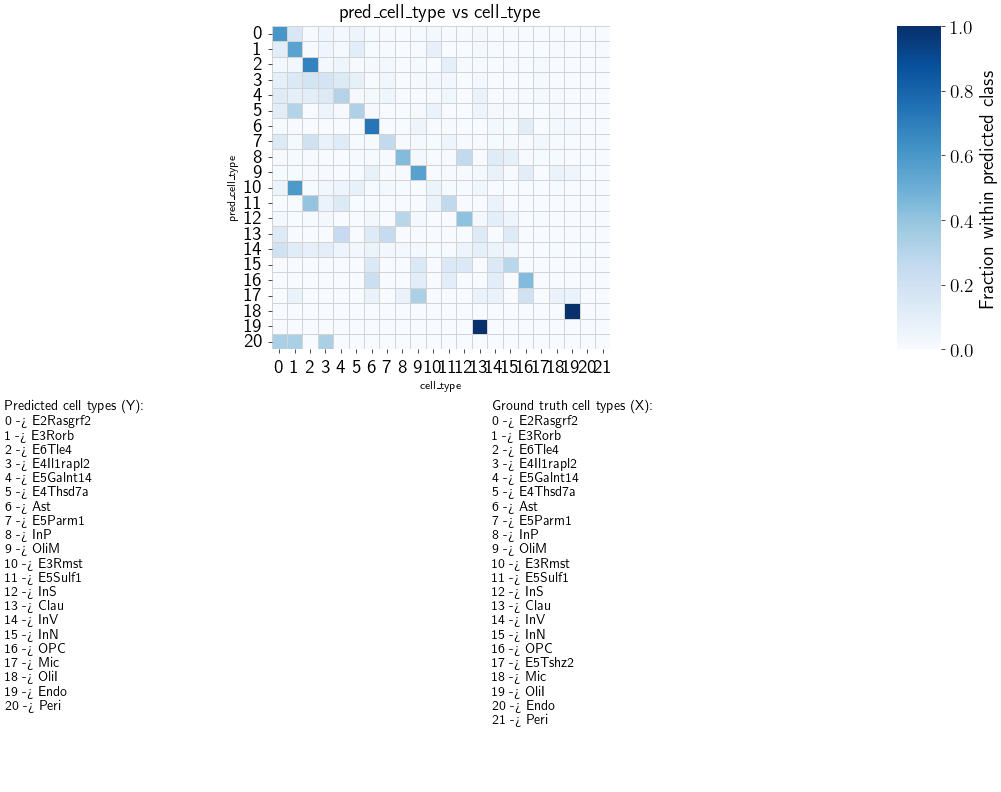

In [30]:
fig, ax, counts_df, norm_df = scb.pl.plot_anndata_confusion(
    adata_1n,
    true_key="cell_type",
    pred_key="pred_cell_type",
    drop_unknown=False,          # key line
    normalize="pred",
    annotate_mapping=True,
    return_data=True,
)

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# 1) Robustify embedding (median/MAD + clipping)
X = adata_1n.obsm["X_cat"].astype(np.float32, copy=True)
med = np.median(X, axis=0)
mad = np.median(np.abs(X - med), axis=0) + 1e-9
Z = (X - med) / (1.4826 * mad)
Z = np.clip(Z, -5, 5).astype(np.float32)
adata_1n.obsm["X_ae_robust"] = Z

# 2) kNN outlier score (mean distance)
k = 30
nbrs = NearestNeighbors(n_neighbors=k).fit(Z)
d, _ = nbrs.kneighbors(Z)
knn_mean = d[:, 1:].mean(1)

# 3) Flag outliers within each reference cell type
ref_mask = adata_1n.obs["cell_type"].to_numpy() != "Unknown"
cell_type = adata_1n.obs["cell_type"].to_numpy()
outlier = np.zeros(len(adata_1n), dtype=bool)

for ct in np.unique(cell_type[ref_mask]):
    idx = np.where(ref_mask & (cell_type == ct))[0]
    if idx.size < 30:  # don’t prune tiny groups
        continue
    thr = np.quantile(knn_mean[idx], 0.98)  # adjust 0.98–0.995
    outlier[idx] = knn_mean[idx] > thr

# 4) Relabel outlier reference cells so they’re not fixed anchors
adata_1n.obs.loc[outlier, "cell_type"] = "Unknown"
adata_1n.obs['cell_type'].value_counts()


cell_type
E2Rasgrf2     2208
E3Rorb        1414
E6Tle4        1162
E4Il1rapl2     607
E5Galnt14      521
E4Thsd7a       460
Ast            435
E5Parm1        338
InP            268
OliM           264
E3Rmst         226
E5Sulf1        218
InS            201
Unknown        191
Clau           143
InV            126
InN             98
OPC             96
E5Tshz2         83
Mic             61
OliI            29
Endo            22
Peri            19
Name: count, dtype: int64

In [ ]:
adata, metrics = scb.ot.integrate(
    adata_1n,
    obsm_key="X_cat",
    batch_key="batch",     
    label_key="cell_type",    
    unlabeled_category="Unknown",    
    out_key="X_supbiot2"    
)


In [33]:
from sklearn.metrics import normalized_mutual_info_score

y_true = adata_1n.obs["cell_type"].astype(str)
y_pred = adata_1n.obs["pred_cell_type"].astype(str)

# keep only valid rows
mask = y_true.notna() & y_pred.notna()

# (optional) ignore "unknown" labels
# mask &= (y_true != "unknown") & (y_pred != "unknown")

nmi = normalized_mutual_info_score(
    y_true[mask].to_numpy(),
    y_pred[mask].to_numpy(),
    average_method="arithmetic",
)

print(f"NMI = {nmi:.6f}")

NMI = 0.329915


In [34]:
methods = ["X_supbiot2"] # , "scBIOT_OT"
leiden_methods = [f'{method}_leiden' for method in methods]

for method, leiden_method in zip(methods, leiden_methods):
    sc.pp.neighbors(adata_1n, use_rep=method)
    sc.tl.umap(adata_1n)
    adata.obsm[f"X_umap_{method}"] = adata.obsm["X_umap"].copy()
    sc.tl.leiden(adata_1n, key_added=leiden_method, resolution=0.8)

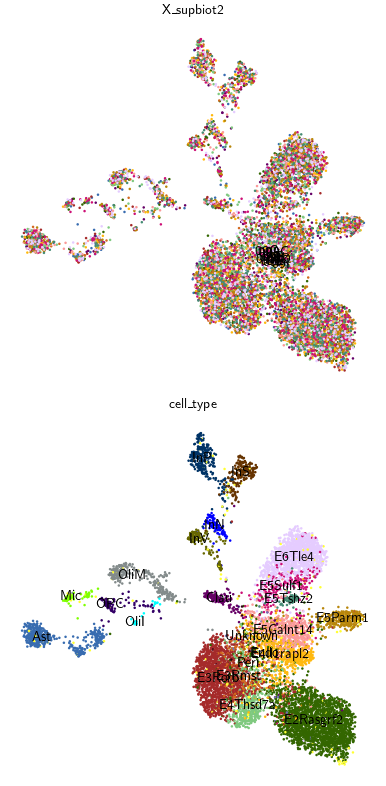

In [35]:
import matplotlib.pyplot as plt
import scanpy as sc


# 2 rows x len(methods) columns
fig, axes = plt.subplots(
    2,
    len(methods),
    figsize=(4 * len(methods), 8),
    squeeze=False  # ensures axes is a 2D array
)

for col, method in enumerate(methods):
    # 1) Top row (row=0): color by "batch"
    sc.pl.embedding(
        adata_1n,
        basis=f"X_umap_{method}",  # The coordinates stored in adata.obsm["X_umap_{method}"]
        color="batch",            # Assume adata.obs["batch"] exists
        frameon=False,
        ax=axes[0, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        title=f"{method}"
    )

    # 2) Bottom row (row=1): color by the Leiden clusters for this method
    leiden_key = f"{method}_leiden"
    sc.pl.embedding(
        adata_1n,
        basis=f"X_umap_{method}",
        color='cell_type',         # Column in adata.obs
        frameon=False,
        ax=axes[1, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        # title=f"{method}"
    )

plt.tight_layout()
# fig.savefig("batch_and_leiden_per_embedding.pdf", dpi=300)
# plt.close(fig)


Embeddings: 100%|██████████| 4/4 [00:46<00:00, 11.55s/it]


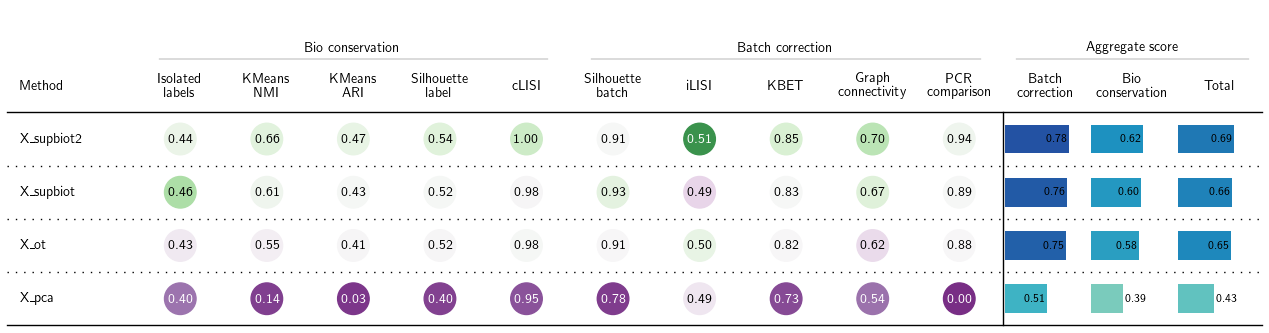

In [ ]:
bm = Benchmarker(
    adata_1n, 
    batch_key="batch",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),    
    embedding_obsm_keys=["X_pca", "X_supbiot", "X_cat", "X_supbiot2"], 
    n_jobs=32
    
)
bm.benchmark()
bm.plot_results_table(min_max_scale=False)